<a href="https://colab.research.google.com/github/carloscifuentesingsoft1560-cyber/Learning_Pytorch/blob/main/modelo_de_regresion_lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cpu'

In [2]:
volumen = 0.8
sesgo = 0.2

inicio = 0
final = 1
step = 0.025
X = torch.arange(start=inicio, end=final, step=step).unsqueeze(dim=1)
print(f"Tamaño de X: {X.shape}")
y = volumen * X + sesgo
print(f"Tamaño de y: {y.shape}")

X[:10], y[:10]

Tamaño de X: torch.Size([40, 1])
Tamaño de y: torch.Size([40, 1])


(tensor([[0.0000],
         [0.0250],
         [0.0500],
         [0.0750],
         [0.1000],
         [0.1250],
         [0.1500],
         [0.1750],
         [0.2000],
         [0.2250]]),
 tensor([[0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800]]))

In [3]:
train_division = int(0.7 *len(X))

x_train, y_train = X[:train_division], y[:train_division]
x_test, y_test = X[train_division:], y[train_division:]


In [4]:

len(x_train), len(y_train), len(x_test), len(y_test)

(28, 28, 12, 12)

In [5]:
def plot_predictions(train_data=x_train,
                     train_labels=y_train,
                     test_data=x_test,
                     test_labels=y_test,
                     predictions=None):
  plt.figure(figsize=(10, 10))
  plt.scatter(train_data, train_labels, color="g",s=4, label="Datos de entrenamiento")
  plt.scatter(test_data, test_labels, c="y", s=4, label="Datos de prueba")

  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=6, label="Predicciones")
    plt.legend(prop={"size": 12});




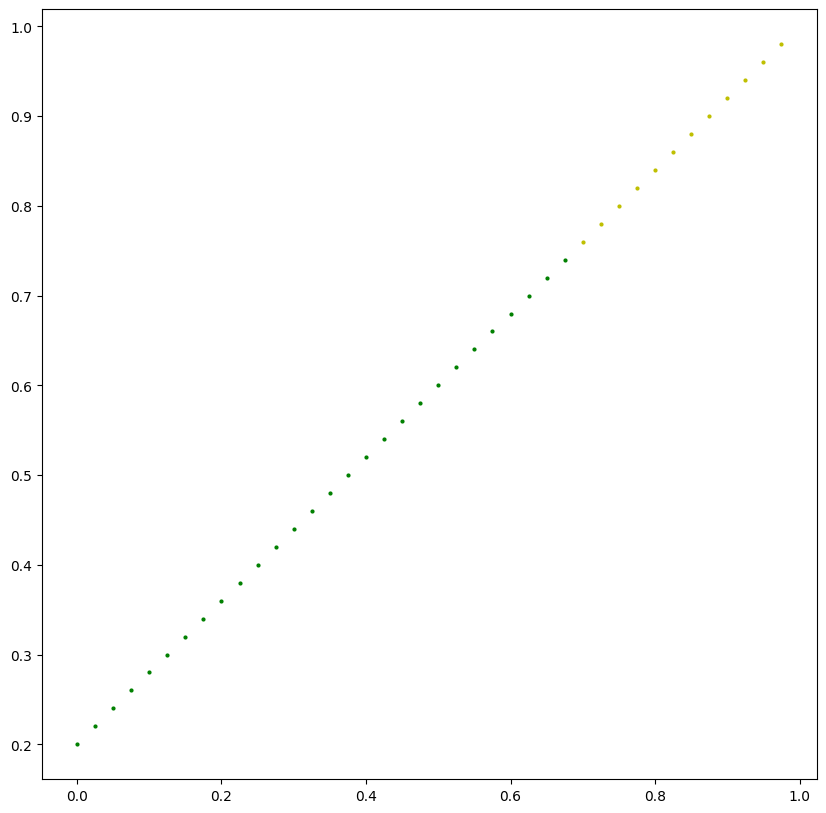

In [6]:
plot_predictions()

In [7]:
class ModeloRegresionLineal(nn.Module):
  def __init__(self) :
    super().__init__()
    self.volumen = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)
    self.sesgo = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

  def forward(self,x:torch.Tensor) -> torch.Tensor:
    return self.volumen * x + self.sesgo

In [8]:
torch.manual_seed(42)

model_1 = ModeloRegresionLineal()


In [9]:
model_1

ModeloRegresionLineal()

In [10]:
model_1.state_dict()

OrderedDict([('volumen', tensor([0.3367])), ('sesgo', tensor([0.1288]))])

In [11]:
with torch.inference_mode():
  y_testc = model_1(x_test)

In [12]:
y_testc

tensor([[0.3645],
        [0.3729],
        [0.3813],
        [0.3897],
        [0.3982],
        [0.4066],
        [0.4150],
        [0.4234],
        [0.4318],
        [0.4402],
        [0.4487],
        [0.4571]])

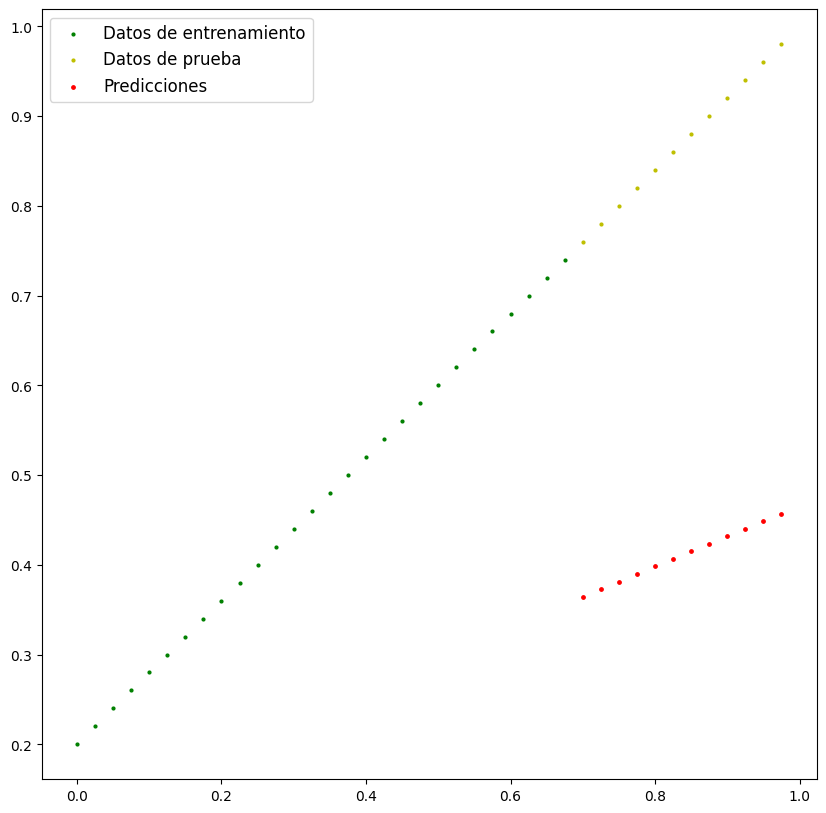

In [13]:
plot_predictions(predictions= y_testc)

In [14]:
fn_perd = torch.nn.L1Loss()


optimizardor = torch.optim.SGD(params=model_1.parameters(), lr=0.01)

In [15]:
torch.manual_seed(42)

epocas = 100


entrenamiento_loss = []

test_loss = []

for epoca in range(epocas):
  model_1.train()
  y_predc = model_1(x_train)
  perdida = fn_perd(y_predc, y_train)
  optimizardor.zero_grad()
  perdida.backward()
  optimizardor.step()
  model_1.eval()

  with torch.inference_mode():
    prueba_perdc = model_1(x_test)
    prueb_perd = fn_perd(prueba_perdc, y_test.type(torch.float))
    if epoca % 10 == 0:
      entrenamiento_loss.append(perdida.detach().numpy())
      test_loss.append(prueb_perd.detach().numpy())

      print(f"epoca: {epoca} | Entrenamiento de pérdida: {perdida} | Test de pérdida: {prueb_perd}")

epoca: 0 | Entrenamiento de pérdida: 0.22755758464336395 | Test de pérdida: 0.44638586044311523
epoca: 10 | Entrenamiento de pérdida: 0.1217288002371788 | Test de pérdida: 0.32246577739715576
epoca: 20 | Entrenamiento de pérdida: 0.07873930037021637 | Test de pérdida: 0.24351508915424347
epoca: 30 | Entrenamiento de pérdida: 0.06662709265947342 | Test de pérdida: 0.20124231278896332
epoca: 40 | Entrenamiento de pérdida: 0.06196669116616249 | Test de pérdida: 0.1784226894378662
epoca: 50 | Entrenamiento de pérdida: 0.05890420451760292 | Test de pérdida: 0.1637665033340454
epoca: 60 | Entrenamiento de pérdida: 0.056116510182619095 | Test de pérdida: 0.15557575225830078
epoca: 70 | Entrenamiento de pérdida: 0.053391676396131516 | Test de pérdida: 0.14738501608371735
epoca: 80 | Entrenamiento de pérdida: 0.05066370964050293 | Test de pérdida: 0.14011786878108978
epoca: 90 | Entrenamiento de pérdida: 0.047930534929037094 | Test de pérdida: 0.1328507363796234


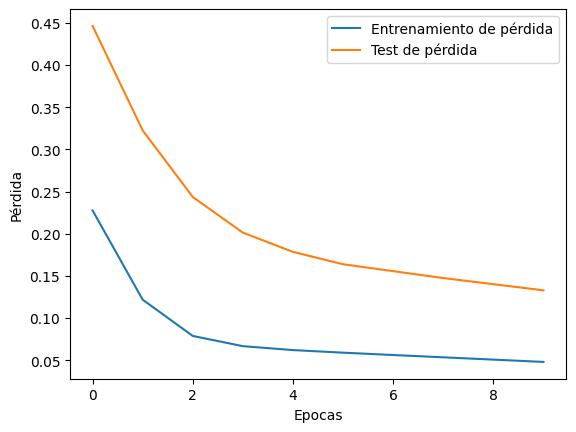

In [16]:
plt.plot(entrenamiento_loss, label="Entrenamiento de pérdida")
plt.plot(test_loss, label="Test de pérdida")
plt.ylabel("Pérdida")
plt.xlabel("Epocas")
plt.legend()
plt.show()

In [19]:
model_1.eval()
with torch.inference_mode():
  # model_1.to(device)
  # x_test = x_test.to(device)
  y_predc = model_1(x_test)

In [20]:
y_predc

tensor([[0.6694],
        [0.6829],
        [0.6965],
        [0.7100],
        [0.7236],
        [0.7371],
        [0.7506],
        [0.7642],
        [0.7777],
        [0.7913],
        [0.8048],
        [0.8184]])

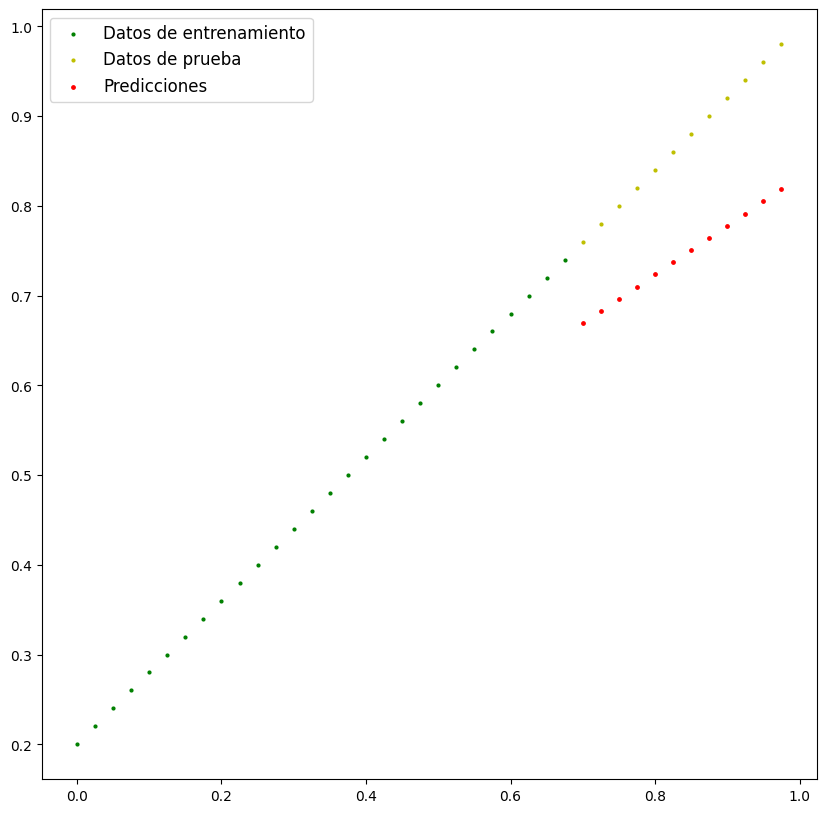

In [21]:
plot_predictions(predictions= y_predc)